#### Name: Venkatappareddy Manukonda

#### Course: MSCS-634 Advanced Big Data and Data Mining

#### Assignment: Clustering Analysis Using K-Means and K-Medoids Algorithms

## Step 1: Load and Prepare the Dataset

Before applying clustering, I wanted to understand the structure of the Wine dataset and prepare the features correctly. Since K-Means and K-Medoids both rely on distance, standardizing the data is important so that features with larger values do not control the clustering results.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

In [3]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

print("Dataset Shape:", X.shape)
print("\nFeature Names:")
print(X.columns.tolist())

print("\nClass Distribution:")
print(y.value_counts().sort_index())

display(X.head())

Dataset Shape: (178, 13)

Feature Names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Class Distribution:
0    59
1    71
2    48
Name: target, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [4]:
print("Descriptive Statistics:")
display(X.describe())

Descriptive Statistics:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [5]:
print("Missing Values:")
print(X.isnull().sum())

print("\nDuplicate Rows:", X.duplicated().sum())

Missing Values:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Duplicate Rows: 0


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardization completed.")

Standardization completed.


### Dataset Summary

The Wine dataset contains 178 samples, 13 chemical features, and 3 target classes. A review of the descriptive statistics shows that the features operate on very different numerical scales. Some variables have values in the hundreds, while others remain below 10. I did not find missing values or duplicate rows, so the main preparation step was standardization. This was important because both K-Means and K-Medoids rely on distance calculations, and features with larger values could otherwise have a much greater influence on cluster formation.

## Step 2: Implement K-Means Clustering

I applied K-Means with k = 3 because the Wine dataset has three known classes. Even though the algorithm does not use the class labels while clustering, using three clusters gives a fair way to compare the discovered groups with the original wine categories.

In [7]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print("K-Means Results")
print("Silhouette Score:", round(kmeans_silhouette, 4))
print("Adjusted Rand Index:", round(kmeans_ari, 4))

K-Means Results
Silhouette Score: 0.2849
Adjusted Rand Index: 0.8975


### K-Means Results

The K-Means results show how well the model grouped the wine samples after standardization. I used the Silhouette Score to understand how separated the clusters were and ARI to see how closely the clusters matched the actual wine classes.

## Step 3: Implement K-Medoids Clustering

Next, I applied K-Medoids with k = 3 so the results could be compared directly with K-Means. I used the same number of clusters for both models because the goal is to compare the algorithms, not change the cluster count.

In [8]:
from sklearn_extra.cluster import KMedoids

kmedoids = KMedoids(
    n_clusters=3,
    random_state=42,
    method="pam"
)

kmedoids_labels = kmedoids.fit_predict(X_scaled)

kmedoids_silhouette = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print("K-Medoids Results")
print("Silhouette Score:", round(kmedoids_silhouette, 4))
print("Adjusted Rand Index:", round(kmedoids_ari, 4))

K-Medoids Results
Silhouette Score: 0.2676
Adjusted Rand Index: 0.7411


### K-Medoids Results

The K-Medoids results give another view of the same clustering problem. Since K-Medoids uses actual observations as cluster centers, it can behave differently from K-Means even when both models use the same value of k.

## Step 4: Visualize and Compare Results

To visualize the clusters, I used PCA to reduce the standardized data into two dimensions. This makes it easier to see how the clusters are positioned and whether the groups appear compact, separated, or overlapping.

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans_centers_pca = pca.transform(kmeans.cluster_centers_)
kmedoids_centers_pca = X_pca[kmedoids.medoid_indices_]

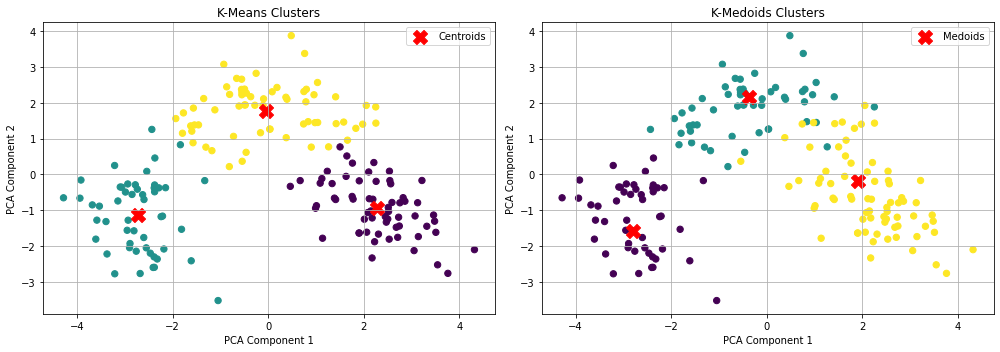

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=40
)
axes[0].scatter(
    kmeans_centers_pca[:, 0],
    kmeans_centers_pca[:, 1],
    c="red",
    marker="X",
    s=200,
    label="Centroids"
)
axes[0].set_title("K-Means Clusters")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")
axes[0].legend()
axes[0].grid(True)

axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmedoids_labels,
    cmap="viridis",
    s=40
)
axes[1].scatter(
    kmedoids_centers_pca[:, 0],
    kmedoids_centers_pca[:, 1],
    c="red",
    marker="X",
    s=200,
    label="Medoids"
)
axes[1].set_title("K-Medoids Clusters")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [11]:
results = pd.DataFrame({
    "Algorithm": ["K-Means", "K-Medoids"],
    "Silhouette Score": [kmeans_silhouette, kmedoids_silhouette],
    "Adjusted Rand Index": [kmeans_ari, kmedoids_ari]
})

results

,Algorithm,Silhouette Score,Adjusted Rand Index
0,K-Means,0.284859,0.897495
1,K-Medoids,0.267622,0.741137


## Comparison of K-Means and K-Medoids

Looking at the results, K-Means performed better than K-Medoids on this dataset. K-Means achieved a Silhouette Score of 0.2849 and an ARI of 0.8975, while K-Medoids achieved a Silhouette Score of 0.2676 and an ARI of 0.7411.

What stood out most was the difference in the ARI values. The K-Means clusters aligned much more closely with the actual wine classes, which suggests that it captured the underlying structure of the dataset more effectively. The Silhouette Scores were relatively close, but K-Means still showed slightly better cluster separation.

The visualizations supported the metric results. Both algorithms were able to identify similar groupings, but the K-Means clusters appeared a little more distinct and better organized. Based on the overall results, K-Means produced the stronger clustering performance in this experiment.

For this dataset, I would choose K-Means because it provided better cluster separation and a much stronger match with the original wine classes. K-Medoids can still be useful when a dataset contains unusual observations or outliers, but the Wine dataset did not appear to benefit from that additional robustness.
